In [1]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

/home/rat/Chess-Assistance/machine_learning/trainer/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Download latest version
path = kagglehub.dataset_download("ahmedalghafri/lichess-chess-games-statistics")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "Chess games stats.csv"))

df.head()

Path to dataset files: /home/rat/.cache/kagglehub/datasets/ahmedalghafri/lichess-chess-games-statistics/versions/1


,Unnamed: 0,Game ID,White Rating,Black Rating,Opening ECO,Opening Ply,White Centi-pawn Loss,White's Number of Inaccuracies,White's Number of Mistakes,White's Number of Blunders,Black Centi-pawn Loss,Black's Number of Inaccuracies,Black's Number of Mistakes,Black's Number of Blunders
0,0,J7Xvjkte,1441,1559,C20,4,32,2,2,0,87,2,4,1
1,1,SSzpi7W1,1258,1567,C46,6,43,0,0,1,6,0,0,0
2,2,NHpcYm3r,1697,1712,C68,7,11,1,0,0,42,1,0,2
3,3,Nrzmgzmn,1978,1868,D31,5,21,3,0,0,53,6,0,1
4,4,xMuFsnC6,2073,1816,A01,2,35,3,2,0,50,6,3,0


In [3]:
df.describe()

,Unnamed: 0,White Rating,Black Rating,Opening Ply,White Centi-pawn Loss,White's Number of Inaccuracies,White's Number of Mistakes,White's Number of Blunders,Black Centi-pawn Loss,Black's Number of Inaccuracies,Black's Number of Mistakes,Black's Number of Blunders
count,18637.000000,18637.000000,18637.000000,18637.000000,18637.000000,18637.000000,18637.000000,18637.000000,18637.000000,18637.000000,18637.000000,18637.000000
mean,9318.000000,1774.528519,1776.729678,5.319043,58.814294,3.258947,1.325643,2.115738,60.778451,3.283254,1.332242,2.118206
std,5380.182819,314.840181,317.424527,3.058254,36.622111,2.404746,1.390271,2.078614,38.316602,2.420974,1.383967,2.094702
min,0.000000,784.000000,780.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4659.000000,1551.000000,1552.000000,3.000000,33.000000,1.000000,0.000000,1.000000,33.000000,1.000000,0.000000,1.000000
50%,9318.000000,1782.000000,1781.000000,5.000000,53.000000,3.000000,1.000000,2.000000,55.000000,3.000000,1.000000,2.000000
75%,13977.000000,1991.000000,1996.000000,7.000000,77.000000,5.000000,2.000000,3.000000,80.000000,5.000000,2.000000,3.000000
max,18636.000000,2997.000000,2995.000000,28.000000,517.000000,19.000000,12.000000,18.000000,550.000000,22.000000,12.000000,22.000000


In [4]:
df.columns

Index(['Unnamed: 0', 'Game ID', 'White Rating', 'Black Rating', 'Opening ECO',
       'Opening Ply', 'White Centi-pawn Loss',
       'White's Number of Inaccuracies', 'White's Number of Mistakes',
       'White's Number of Blunders', 'Black Centi-pawn Loss',
       'Black's Number of Inaccuracies', 'Black's Number of Mistakes',
       'Black's Number of Blunders'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18637 entries, 0 to 18636
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      18637 non-null  int64 
 1   Game ID                         18637 non-null  object
 2   White Rating                    18637 non-null  int64 
 3   Black Rating                    18637 non-null  int64 
 4   Opening ECO                     18637 non-null  object
 5   Opening Ply                     18637 non-null  int64 
 6   White Centi-pawn Loss           18637 non-null  int64 
 7   White's Number of Inaccuracies  18637 non-null  int64 
 8   White's Number of Mistakes      18637 non-null  int64 
 9   White's Number of Blunders      18637 non-null  int64 
 10  Black Centi-pawn Loss           18637 non-null  int64 
 11  Black's Number of Inaccuracies  18637 non-null  int64 
 12  Black's Number of Mistakes      18637 non-null

In [6]:
df.isna().sum()

Unnamed: 0                        0
Game ID                           0
White Rating                      0
Black Rating                      0
Opening ECO                       0
Opening Ply                       0
White Centi-pawn Loss             0
White's Number of Inaccuracies    0
White's Number of Mistakes        0
White's Number of Blunders        0
Black Centi-pawn Loss             0
Black's Number of Inaccuracies    0
Black's Number of Mistakes        0
Black's Number of Blunders        0
dtype: int64

/tmp/ipykernel_6819/1850562217.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


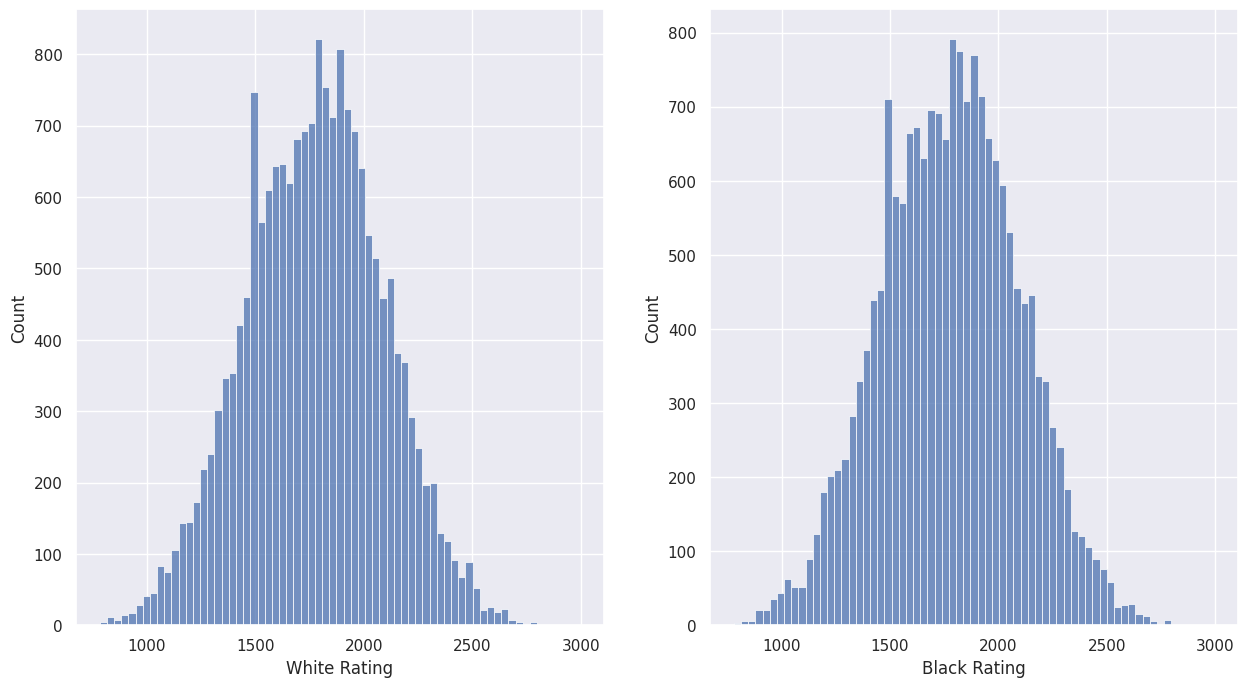

In [7]:
sns.set(rc = {'figure.figsize':(15,8)})
fig, ax=plt.subplots(1,2)
sns.histplot(df, x="White Rating", ax=ax[0])
sns.histplot(df, x="Black Rating", ax=ax[1])
fig.show()


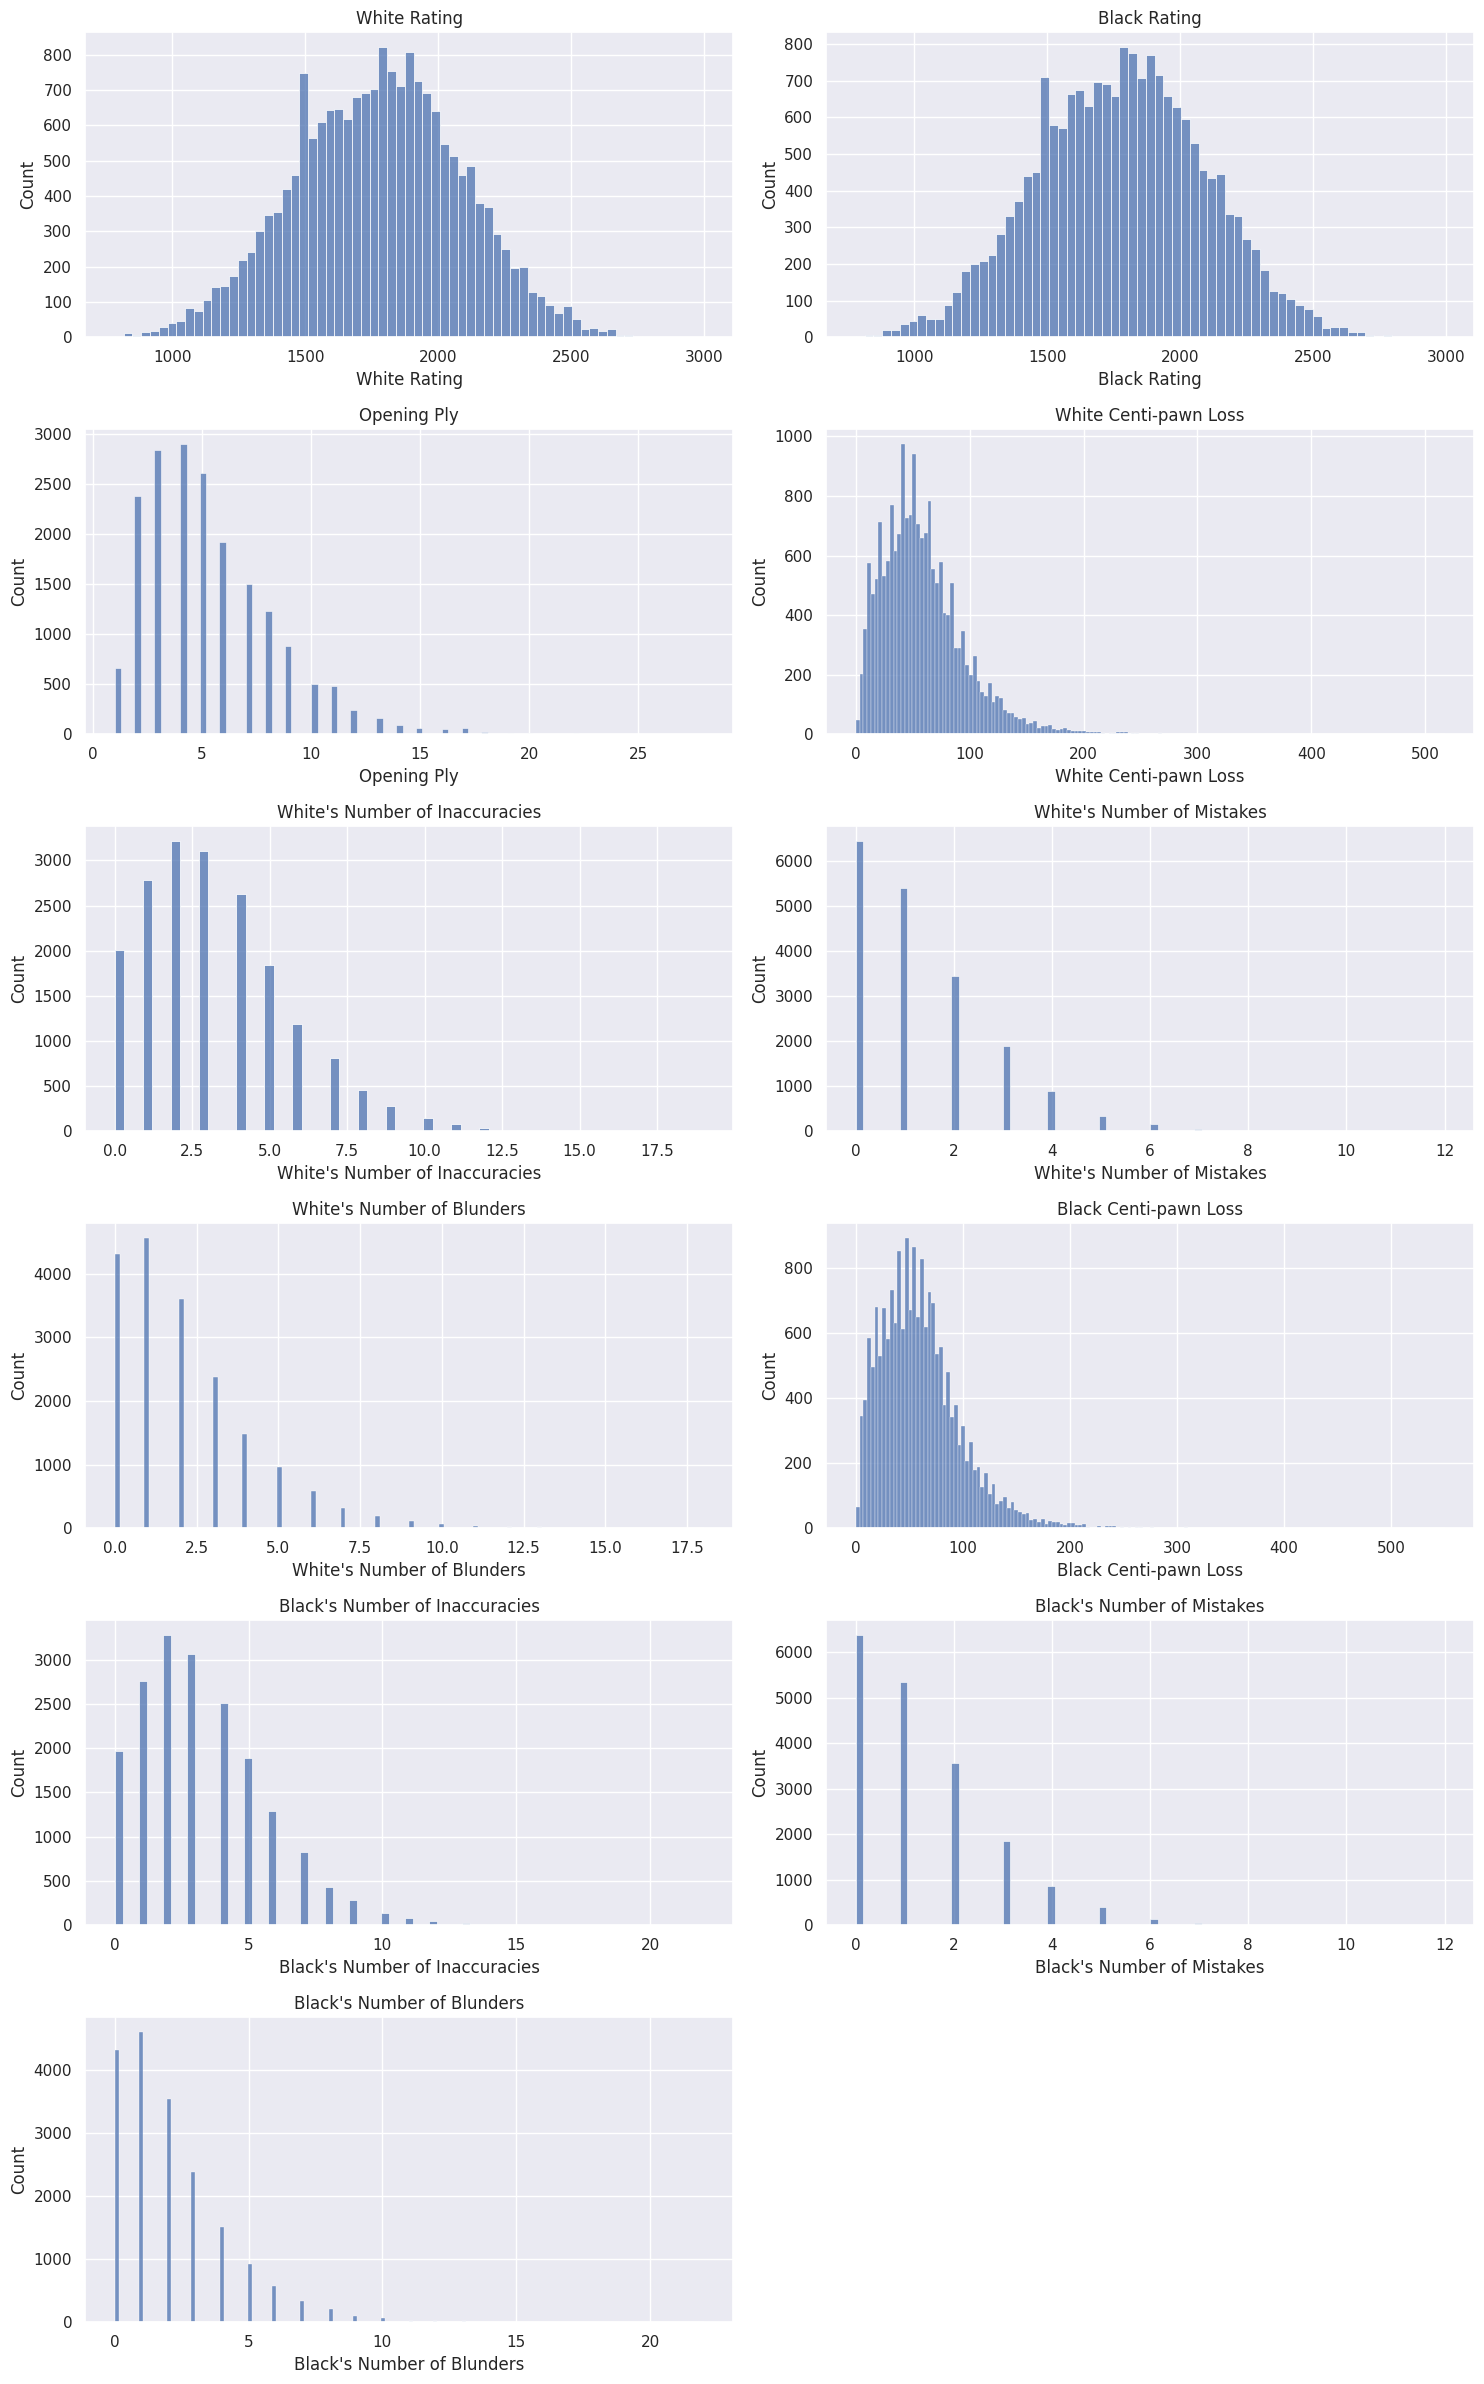

In [8]:
numeric_cols = df.select_dtypes(include='number').columns.drop('Unnamed: 0')
n_cols = 2
n_rows = (len(numeric_cols) + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df, x=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

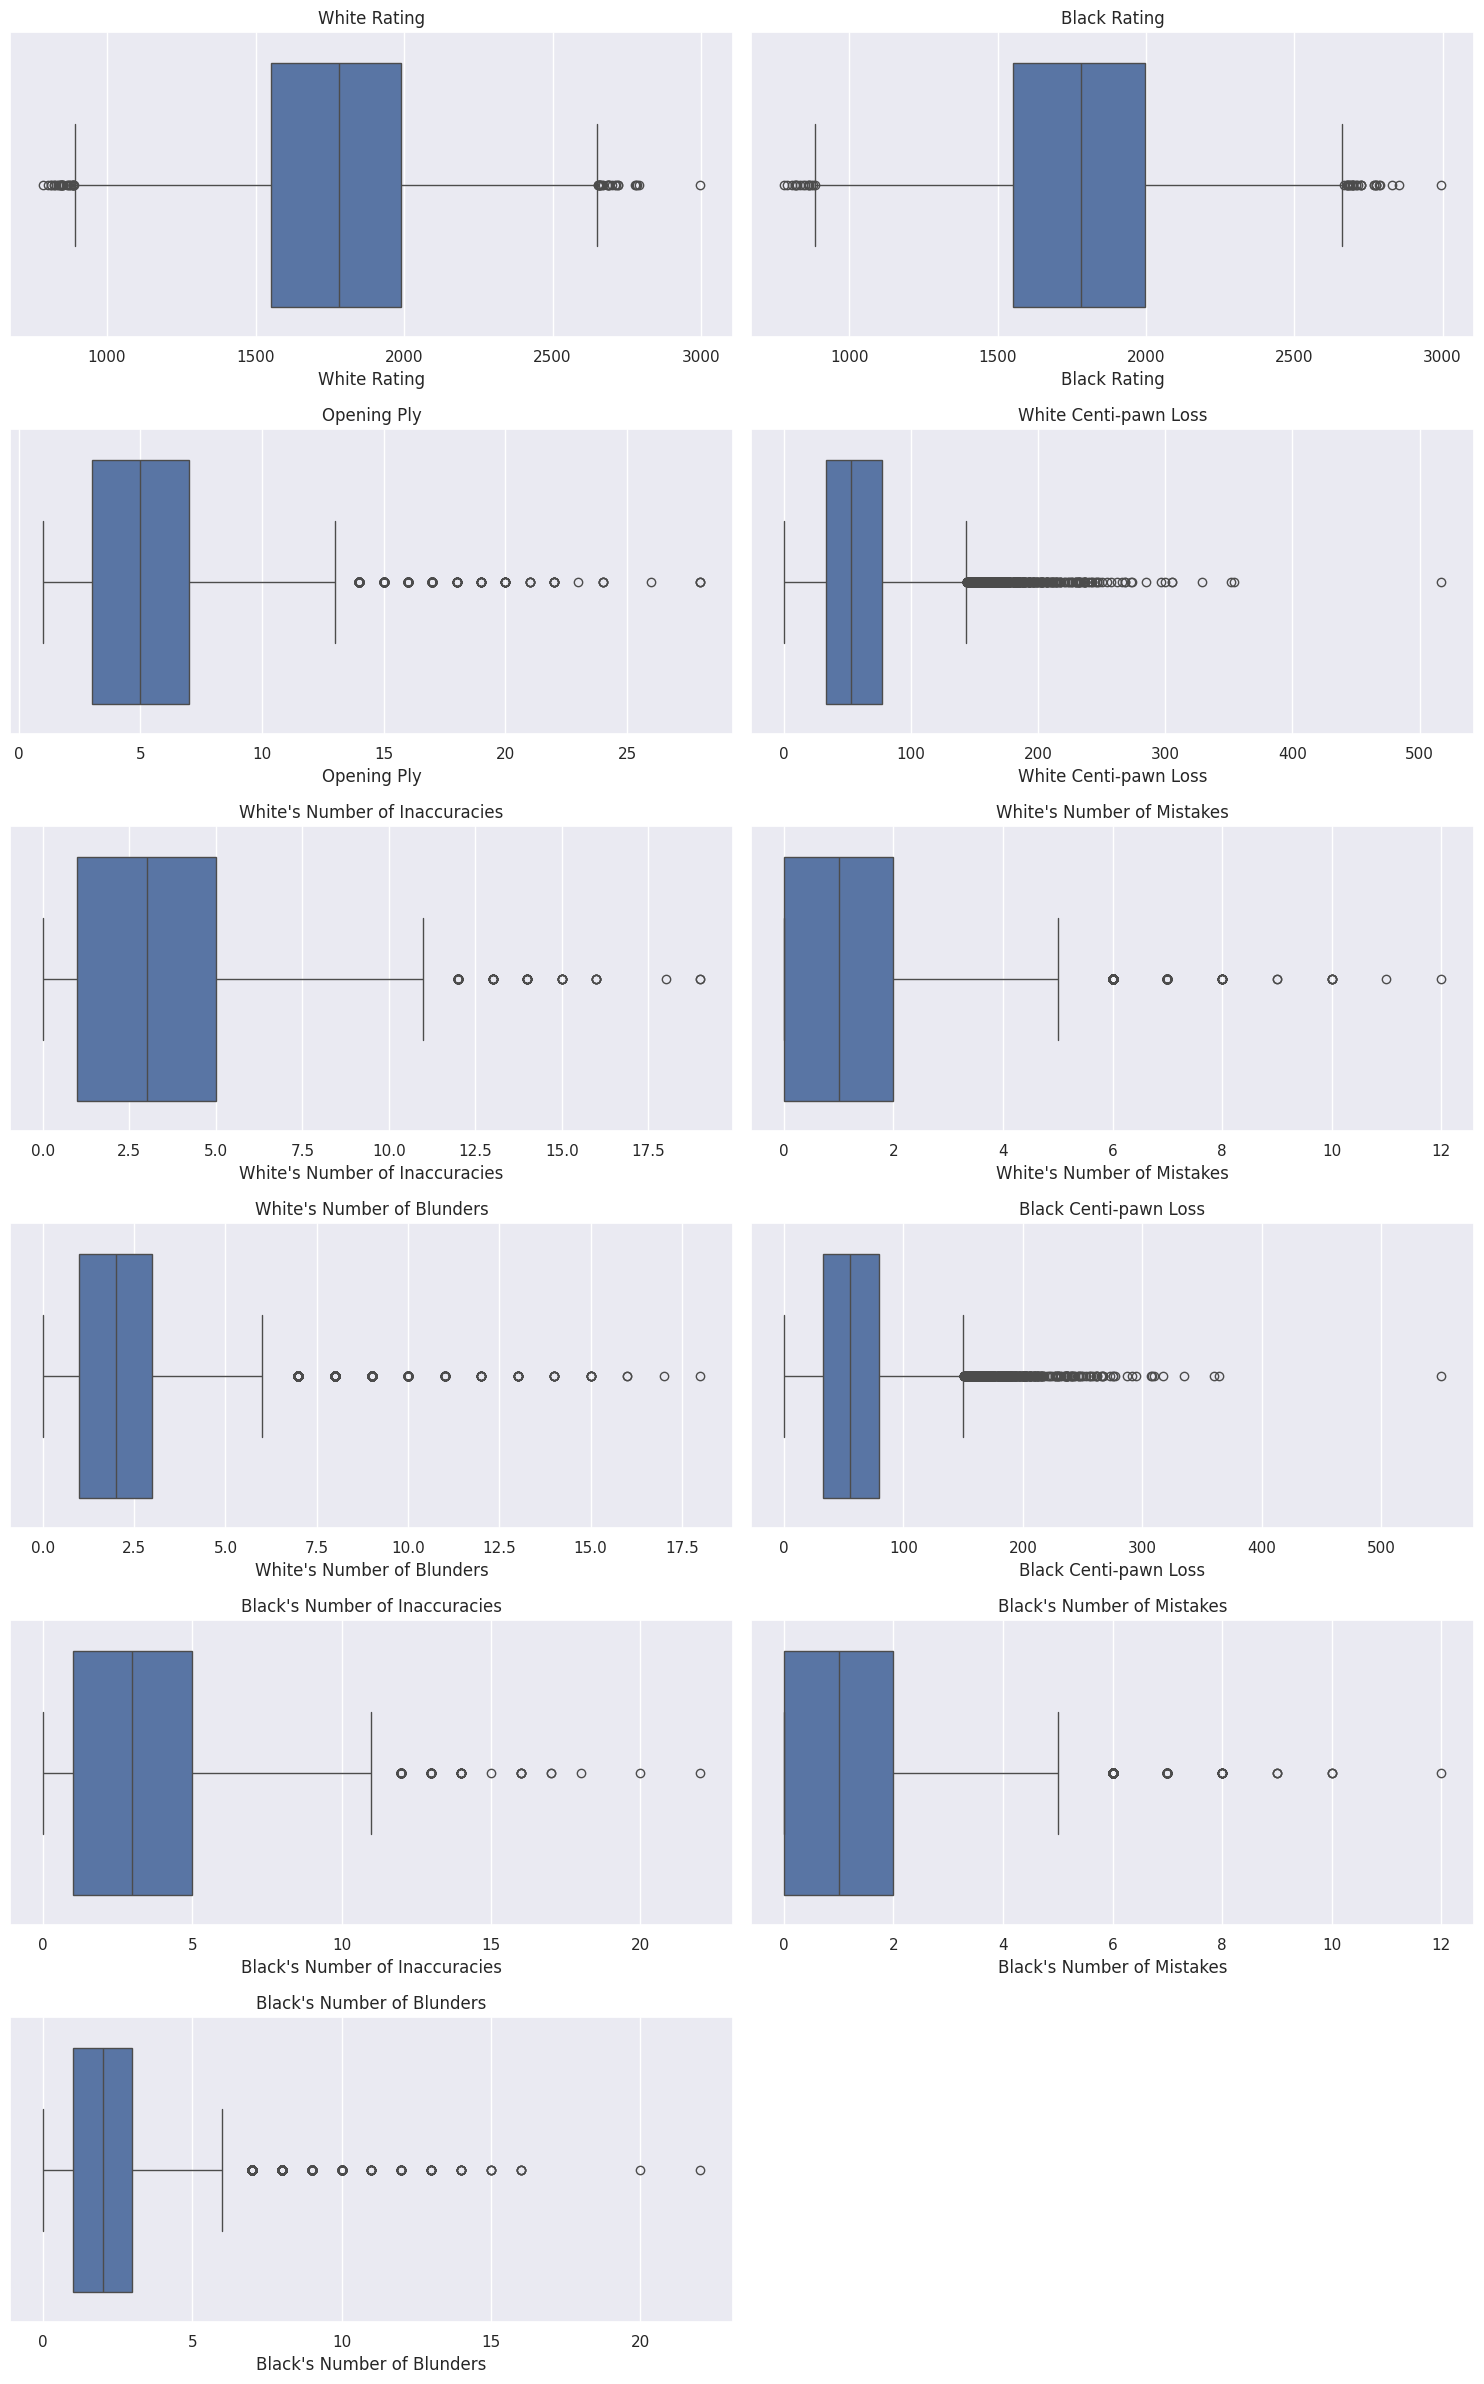

In [9]:
numeric_cols = df.select_dtypes(include='number').columns.drop('Unnamed: 0')
n_cols = 2
n_rows = (len(numeric_cols) + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(df, x=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

We can see that we have mostly right skewed data so I will try to log or sqrt transform it.

From analyzing the Business requirements we will try to predict user's centipawn loss.

Some thinks that I would try to add to this dataset:
-Add time control to each game (blitz, rapid, classical chess)
-try to add clustering to either get rid of outliers or classify games and then use it as another column
-Add data from berserk lib (lib for interacting with lichess api) 
-Add maybe the most common opening for each elo ?


White Rating                      => Gaussian distribution, might be very useful to predict centipawn loss. Maybe the relationship between rating and centipawn loss (which is very simmilar to accuracy) is linear 
Black Rating                      => The same case as in White Rating
Opening ECO                       => I assume it will be very useful. Some openings are harder than the others or even some openings are generally considered bad. It might be good idea to possibly make up a feature that for each elo range quantifies how hard the opening is ?
Opening Ply                       => I assume it will be correlated with centipawn loss. The more moves are according to chess theory the less centipawn loss is, as these moves are considered "engine moves"
White Centi-pawn Loss             => target var
White's Number of Inaccuracies    => It is highly correlated with target var, but should I use it ?
White's Number of Mistakes        => Same as inaccuracies
White's Number of Blunders        => Same as blunders
Black Centi-pawn Loss             => target var
Black's Number of Inaccuracies    => the same case in white
Black's Number of Mistakes        => the same case in white
Black's Number of Blunders        => the same case in white
dtype: int64

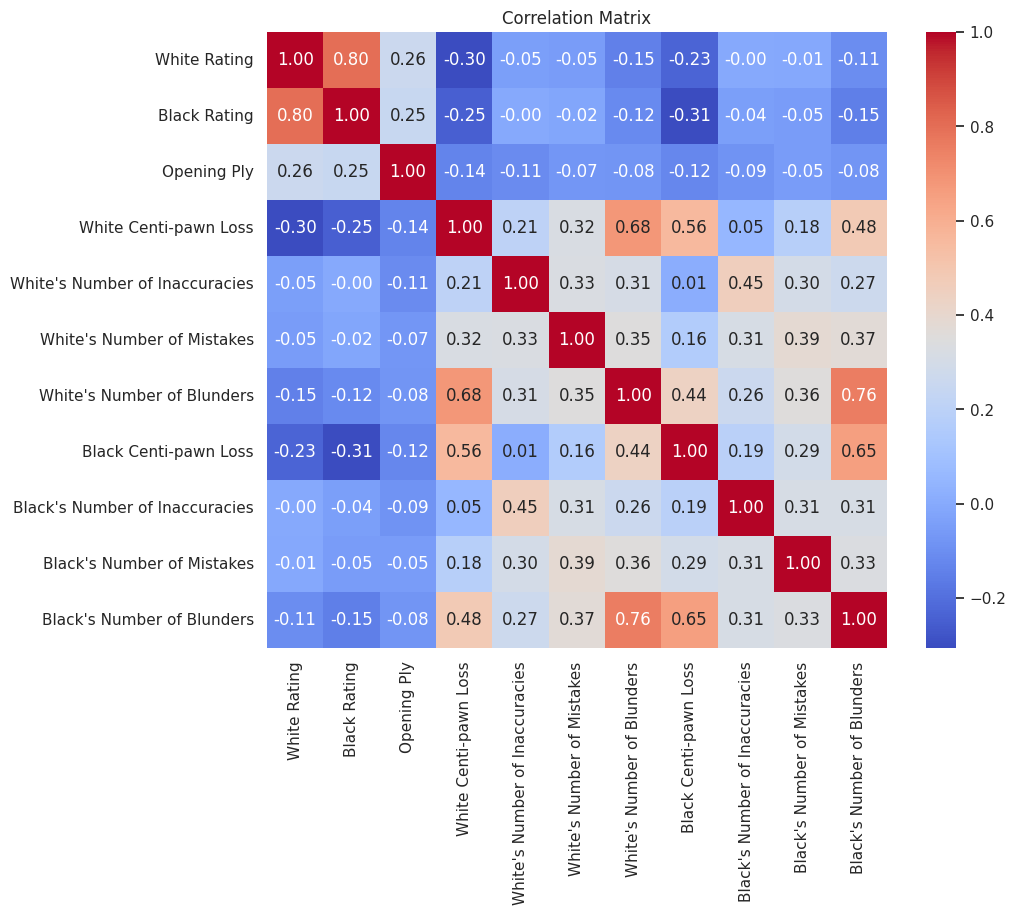

In [10]:
df_corr = df.drop(columns=['Unnamed: 0','Game ID', 'Opening ECO']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()     

Based on correlation matrix we can see couple of interesting correlations

Black's number of blunders is highly correlated with white's number of blunders.
This may be due to the fact that in online chess typically are matched with people on similar level. If player A makes a lot of blunders, this would typically mean that they are "weak" player. Because player B and player A are typically on similar skill level, this means that player B probably makes a lot of mistakes too.

Number of moves following theory is correlated with player's ratings. Number of moves following theory is slightly correlated with players centipawn loss.

We can reach the obvious conclusion here which is : 
Better players make less mistakes
Worse players make more mistakes

However we did not analyse the effect of the opening on player's accuracy yet.

In [11]:
df['Opening ECO'].nunique()

417

In [12]:
df['Opening ECO'].value_counts().head(10)

#I dont get these codes so let me just 

Opening ECO
D00    685
A00    643
C00    639
B01    636
B00    567
C50    558
A40    516
C41    502
B20    492
A45    383
Name: count, dtype: int64

# Start some feature engineering

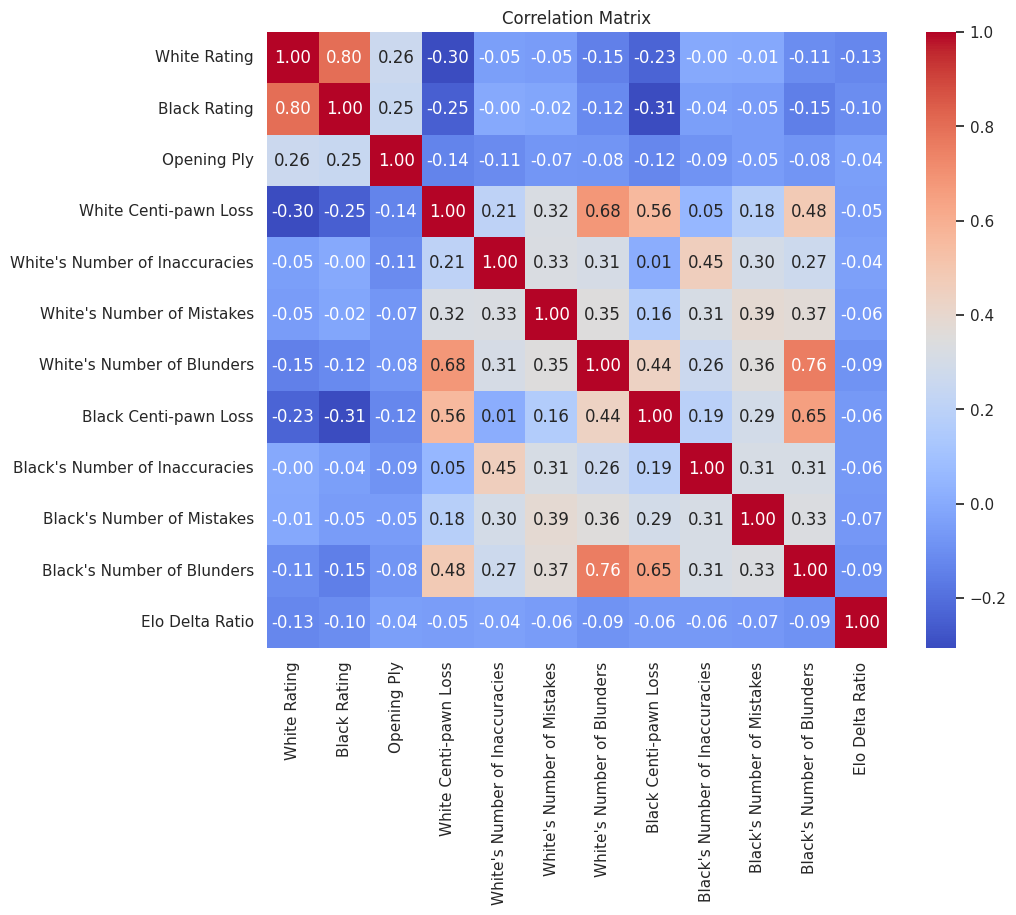

In [13]:

#Maybe I can just add a new column that shows the relative difference between the white and black ratings, and then see how it correlates with the other columns
df['Elo Delta Ratio'] = abs(df['White Rating'] - df['Black Rating']) / ((df['White Rating'] + df['Black Rating']) / 2)

df_corr = df.drop(columns=['Unnamed: 0','Game ID', 'Opening ECO']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()     

## Opening Frequency Feature

Classifies each game based on how commonly the opening is played:
- **top_5** — one of the 5 most played openings in the dataset
- **bottom_5** — one of the 5 least played openings in the dataset
- **other** — everything else

Then we encode this as an ordinal feature and look at its correlation with centipawn losses.

In [14]:
opening_counts = df['Opening ECO'].value_counts()

#I am  splitting the data into 3 buckets each having 33% of the classes
#Maybe should I split the bucket into having 33% of the games instead of 33% of the classes? It may be more useful
opening_terciles = pd.qcut(opening_counts, q=3, labels=['rare', 'moderate', 'common'])
opening_bucket_map = opening_terciles.to_dict()

df['Opening Frequency Class'] = df['Opening ECO'].map(opening_bucket_map)

print("Tercile thresholds (games played per opening):")
print(pd.qcut(opening_counts, q=3).value_counts().sort_index())
print()
print("Games per bucket:")
print(df['Opening Frequency Class'].value_counts())

Tercile thresholds (games played per opening):
count
(0.999, 4.0]       148
(4.0, 20.333]      130
(20.333, 685.0]    139
Name: count, dtype: int64

Games per bucket:
Opening Frequency Class
common      16898
moderate     1430
rare          309
Name: count, dtype: int64


In [15]:
ordinal_map = {'rare': 0, 'moderate': 1, 'common': 2}
df['Opening Frequency Encoded'] = df['Opening Frequency Class'].map(ordinal_map)

In [16]:
df = df.drop(columns=['Opening Frequency Class',"White's Number of Inaccuracies","White's Number of Mistakes","White's Number of Blunders","Black's Number of Inaccuracies","Black's Number of Mistakes","Black's Number of Blunders",'Unnamed: 0','Game ID', 'Opening ECO']
)
df.head()


,White Rating,Black Rating,Opening Ply,White Centi-pawn Loss,Black Centi-pawn Loss,Elo Delta Ratio,Opening Frequency Encoded
0,1441,1559,4,32,87,0.078667,2
1,1258,1567,6,43,6,0.218761,2
2,1697,1712,7,11,42,0.008800,2
3,1978,1868,5,21,53,0.057202,2
4,2073,1816,2,35,50,0.132168,2


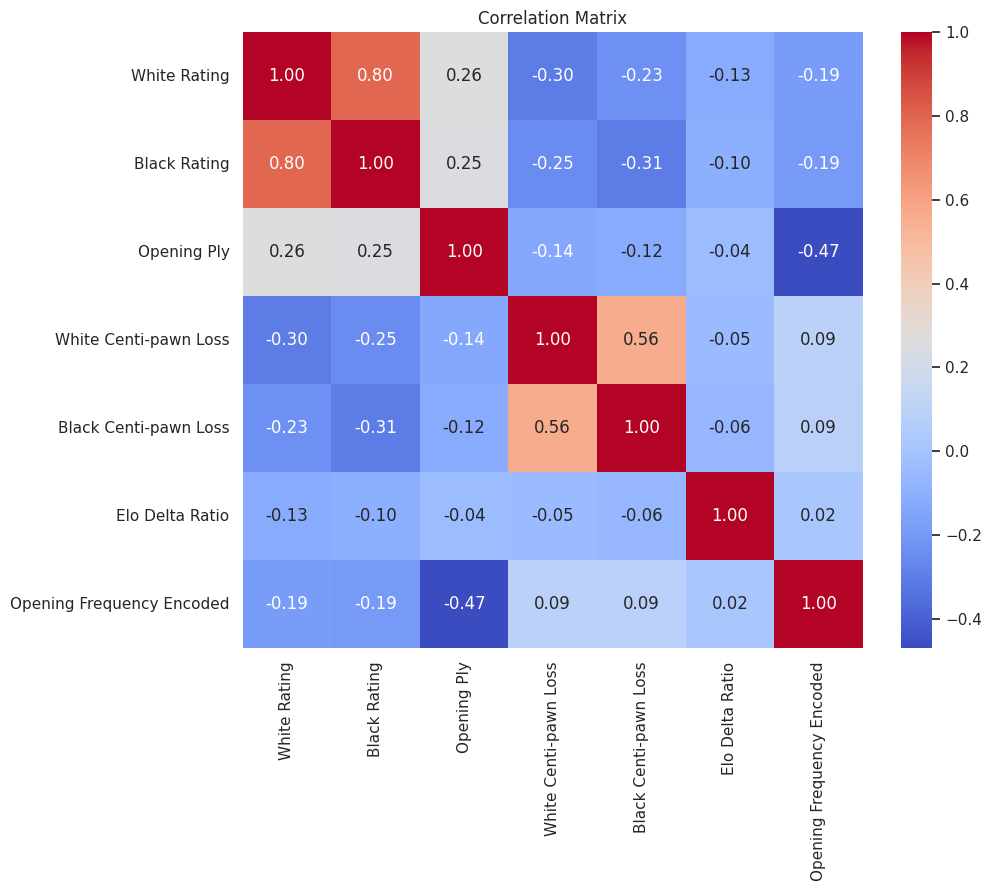

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()     

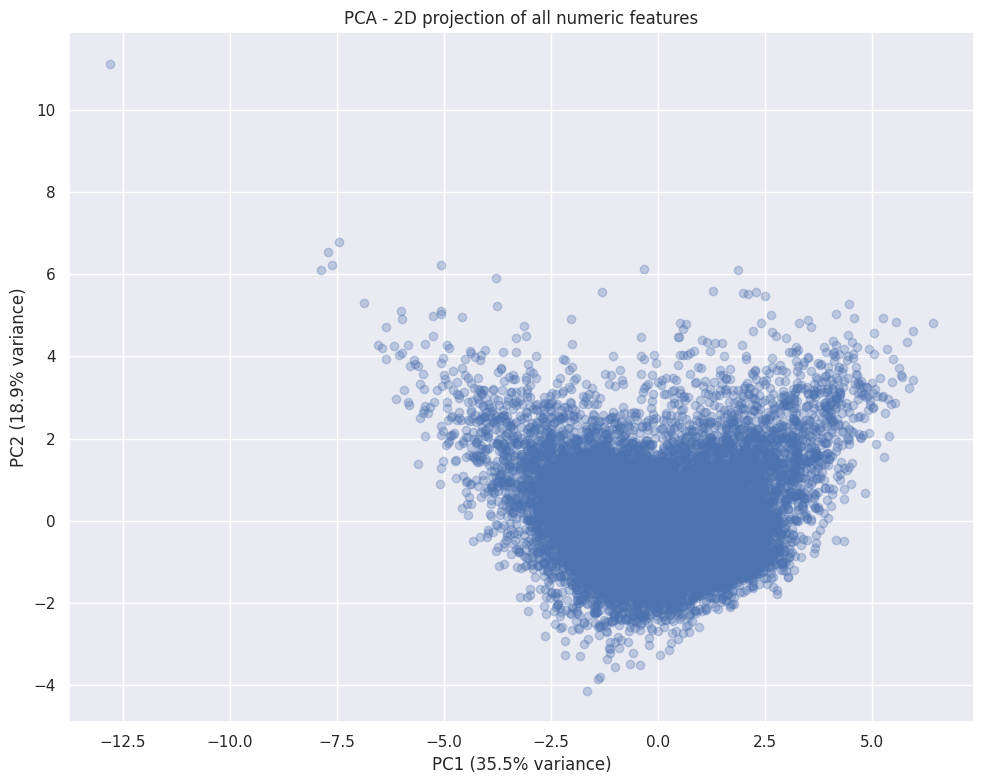

In [18]:
numeric_cols = df.select_dtypes(include='number').columns  
df_scaled = StandardScaler().fit_transform(df[numeric_cols])
pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(components[:, 0], components[:, 1], alpha=0.3)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA - 2D projection of all numeric features')
plt.tight_layout()
plt.show()

Todo: Transform the data so it is like that : player_white,player_rating, opponent_rating, opening_played, elo_delta_ratio, opening_frequency_global


Then add features like :
-how much user played the opening
-etc. etc.

Try RandomForestRegressor and check the most impactful features

In [19]:
white_df = pd.DataFrame({
    'player_rating':           df['White Rating'],
    'opponent_rating':         df['Black Rating'],
    'player_white':            1,
    'opening_ply':             df['Opening Ply'],
    'elo_delta_ratio':         df['Elo Delta Ratio'],
    'opening_frequency':       df['Opening Frequency Encoded'],
    'player_centipawn_loss':   df['White Centi-pawn Loss'],
    'opponent_centipawn_loss': df['Black Centi-pawn Loss'],
})

black_df = pd.DataFrame({
    'player_rating':           df['Black Rating'],
    'opponent_rating':         df['White Rating'],
    'player_white':            0,
    'opening_ply':             df['Opening Ply'],
    'elo_delta_ratio':         df['Elo Delta Ratio'],
    'opening_frequency':       df['Opening Frequency Encoded'],
    'player_centipawn_loss':   df['Black Centi-pawn Loss'],
    'opponent_centipawn_loss': df['White Centi-pawn Loss'],
})

df_player = pd.concat([white_df, black_df], ignore_index=True)

print(f"Shape: {df_player.shape}  ({len(df)} games × 2 players)")
df_player.head(10)

Shape: (37274, 8)  (18637 games × 2 players)


,player_rating,opponent_rating,player_white,opening_ply,elo_delta_ratio,opening_frequency,player_centipawn_loss,opponent_centipawn_loss
0,1441,1559,1,4,0.078667,2,32,87
1,1258,1567,1,6,0.218761,2,43,6
2,1697,1712,1,7,0.008800,2,11,42
3,1978,1868,1,5,0.057202,2,21,53
4,2073,1816,1,2,0.132168,2,35,50
5,1944,2052,1,9,0.054054,2,79,62
6,1500,2058,1,6,0.313659,2,50,91
7,1880,1919,1,7,0.020532,1,9,49
8,2209,2185,1,7,0.010924,2,93,71
9,2296,2323,1,6,0.011691,1,65,32
